# Deep Learning Project: Predicting if a bank customer will exit the bank

## Importing the libraries

In [156]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

import wandb
from wandb.integration.keras import WandbMetricsLogger

from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## set up wandb

In [157]:
!pip install wandb -q

In [158]:
wandb.login()


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

## Importing the dataset

In [159]:
dataset = pd.read_csv("Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

#print(X)
#print(Y)

## Data preprocessing

### Splitting the data into train & test

In [160]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Replace missing data

In [161]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography & gender column

In [162]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [163]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Building the Nerual Network

#### A feedforward neural network is constructed with:


*   An input layer that receives the preprocessed feature vectors.
*   Two fully connected hidden layers (64 and 32 neurons) using the ReLU activation function.


*   One output layer with a single neuron using the Sigmoid activation function for binary classification.

#### The ReLU activation function is used in the hidden layers to introduce non-linearity and enable the network to learn complex patterns from the data. The Sigmoid activation function is applied in the output layer to produce probability values between 0 and 1, making it suitable for predicting binary outcomes.






### Initializing the ANN

In [164]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [165]:
tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Dense name=dense, built=False>

### Adding the second hidden layer

In [166]:
model.add(tf.keras.layers.Dense(units=32, activation='relu'))

### Adding the output layer

In [167]:
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

## Handling Class Imbalance with Oversampling (SMOTE)

#### To handle class imbalance, we apply SMOTE, which generates synthetic samples for the minority (churn) class. This balances the training data and helps the model better detect churn cases.

#### This approach improves recall and reduces false negatives.

#### SMOTE is applied only to the training set to avoid data leakage.

In [168]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Before SMOTE:", np.bincount(y_tr))

smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.6)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

print("After  SMOTE:", np.bincount(y_tr_sm))

Before SMOTE: [5096 1304]
After  SMOTE: [5096 3057]


### Compiling the ANN

#### The model is compiled using:


*   Adam optimizer with learning rate 0.001 for efficient gradient updates.
*   Binary Crossentropy loss, suitable for binary classification tasks.
*   Evaluation metrics including Accuracy, Precision, Recall, and AUC to comprehensively assess performance.



In [169]:
tf.keras.backend.clear_session()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

## Training the ANN on the Training set

### Callbacks - Saving checkpoint

In [170]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Experiment Tracking Configuration (WandB)

In [171]:
RUN_NAME = "model_1_exp_2"

wandb.init(
    project="bank_customers_churn",
    name=RUN_NAME,
    config={
        "model_id": 1,
        "architecture": "64-32-relu + sigmoid",
        "epochs": 50,
        "batch_size": 128,
        "learning_rate": 0.001,
        "optimizer": "adam",
        "loss": "binary_crossentropy"
    }
)

wandb_callback = WandbMetricsLogger()

epoch/accuracy,▁▆▇▇▇▇▇▇▇███████████████████████████████
epoch/auc,▁▃▅▅▆▆▆▇▇▇▇▇▇▇██████████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/precision,▁▅▇▇▇▇▇█████████████████████████████████
epoch/recall,█▁▁▂▂▃▃▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▇▆▇▆▇▆▇▇▇▇▇▇▇▇▇
epoch/val_accuracy,▁▃▄▄▄▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██▇▇█▇█▇▇███▇█████
epoch/val_auc,▁▃▄▄▅▆▆▆▆▇▇▇▇▇▇▇▇███████████████████████
epoch/val_loss,█▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


### Train the model

In [172]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[checkpoint, wandb_callback]
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4463 - auc: 0.5688 - loss: 0.7809 - precision: 0.2246 - recall: 0.6969 - val_accuracy: 0.7550 - val_auc: 0.6273 - val_loss: 0.5557 - val_precision: 0.3540 - val_recall: 0.2454
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7688 - auc: 0.6338 - loss: 0.5334 - precision: 0.3664 - recall: 0.1454 - val_accuracy: 0.8012 - val_auc: 0.6862 - val_loss: 0.4794 - val_precision: 0.5741 - val_recall: 0.0951
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8050 - auc: 0.6882 - loss: 0.4732 - precision: 0.6201 - recall: 0.0841 - val_accuracy: 0.8062 - val_auc: 0.7169 - val_loss: 0.4562 - val_precision: 0.6538 - val_recall: 0.1043
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8044 - auc: 0.7162 - loss: 0.4559 - precision: 0.6050 - recall: 0.0947 - val_accuracy: 0.8125 - val_auc: 0.7352 - val_loss: 0.4449 - val_precision: 0.6585 - val_recall: 0.1656
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0

### Performance Visualization - Training and Validation Curves

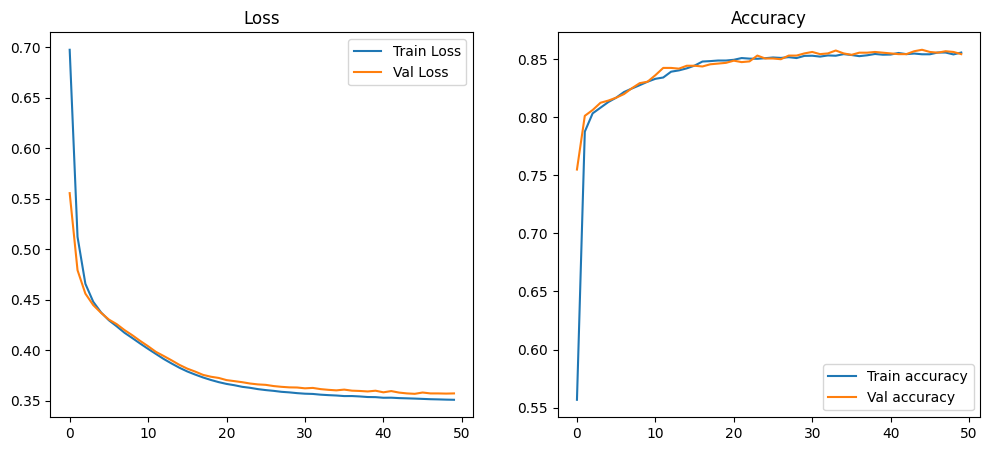

In [173]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.legend()
plt.title("Accuracy")

plt.show()

#### The training and validation loss decrease rapidly in the initial epochs and then gradually converge to approximately 0.35, indicating stable and consistent learning behavior. The validation loss remains slightly lower than the training loss throughout training, and the small gap between the curves suggests good generalization without signs of overfitting.

#### Accuracy increases sharply at the beginning and stabilizes around 85–86% for both training and validation sets. The validation accuracy is consistently slightly higher than the training accuracy, and the close alignment of the curves reflects stable and reliable performance of the baseline model.

### Hyperparameters table

In [174]:
import pandas as pd

hyperparameters = {
    "Parameter": [
        "Model ID",
        "Hidden Layer 1 Units",
        "Hidden Layer 2 Units",
        "Activation Function (Hidden)",
        "Output Activation",
        "Optimizer",
        "Learning Rate",
        "Loss Function",
        "Batch Size",
        "Epochs"
    ],
    "Value": [
        "Model-1 (exp2)",
        64,
        32,
        "ReLU",
        "Sigmoid",
        "Adam",
        0.001,
        "Binary Crossentropy",
        128,
        50
    ]
}

hp_table = pd.DataFrame(hyperparameters)
hp_table


,Parameter,Value
0,Model ID,Model-1 (exp2)
1,Hidden Layer 1 Units,64
2,Hidden Layer 2 Units,32
3,Activation Function (Hidden),ReLU
4,Output Activation,Sigmoid
5,Optimizer,Adam
6,Learning Rate,0.001
7,Loss Function,Binary Crossentropy
8,Batch Size,128
9,Epochs,50


## Predicting and evaluating the model


### Find the best threshold

In [180]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix

# ===== 1) find best threshold on VAL =====
y_val_prob = model.predict(X_val).ravel()

thresholds = np.linspace(0.05, 0.95, 181)
min_recall_pos = 0.6

best_t = None
best_macro_f1 = -1
best_stats = None

for t in thresholds:
    y_val_pred = (y_val_prob >= t).astype(int)

    # macro F1
    _, _, f1_macro, _ = precision_recall_fscore_support(
        y_val, y_val_pred, average="macro", zero_division=0
    )

    # positive-class precision/recall/f1
    p1, r1, f11, _ = precision_recall_fscore_support(
        y_val, y_val_pred, average="binary", zero_division=0
    )

    if r1 >= min_recall_pos and f1_macro > best_macro_f1:
        best_macro_f1 = f1_macro
        best_t = t
        best_stats = (p1, r1, f11)

print("Best threshold:", best_t)
print("VAL macro F1:", best_macro_f1)
print("VAL pos P/R/F1:", best_stats)

# ===== 2) evaluate on TEST using that threshold =====
y_test_prob = model.predict(X_test).ravel()
y_test_pred = (y_test_prob >= best_t).astype(int)

print("\nTEST report @ threshold =", best_t)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best threshold: 0.31999999999999995
VAL macro F1: 0.7481372149410654
VAL pos P/R/F1: (0.595166163141994, 0.6042944785276073, 0.5996955859969558)
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

TEST report @ threshold = 0.31999999999999995


### Confusion Matrix Analysis

In [182]:

print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))


Confusion Matrix:
 [[1418  175]
 [ 158  249]]


#### This means:


*   True Negatives (TN): 1418
*   False Positives (FP): 175
*   False Negatives (FN): 158
*   True Positives (TP): 249
#### The model performs very well in identifying the majority class (Class 0), but it struggles to correctly detect the minority class (Class 1).





### Performance metrics

In [183]:
results = model.evaluate(X_test, y_test, verbose=0)
print("Test Results (loss, acc, precision, recall, auc):\n", results)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC-AUC:", roc_auc)

Test Results (loss, acc, precision, recall, auc):
 [0.3572385013103485, 0.859499990940094, 0.7916666865348816, 0.4201474189758301, 0.8418765664100647]

Classification Report:

              precision    recall  f1-score   support

           0     0.8997    0.8901    0.8949      1593
           1     0.5873    0.6118    0.5993       407

    accuracy                         0.8335      2000
   macro avg     0.7435    0.7510    0.7471      2000
weighted avg     0.8362    0.8335    0.8348      2000

ROC-AUC: 0.8417277061344857


### rcord resualts in wandb

In [185]:
import wandb
from sklearn.metrics import f1_score, precision_score, recall_score

macro_f1 = f1_score(y_test, y_test_pred, average="macro")
precision_pos = precision_score(y_test, y_test_pred)
recall_pos = recall_score(y_test, y_test_pred)

wandb.log({
    "best_threshold": best_t,
    "test_macro_f1": macro_f1,
    "test_precision_pos": precision_pos,
    "test_recall_pos": recall_pos,
})


### Plotting ROC Curve

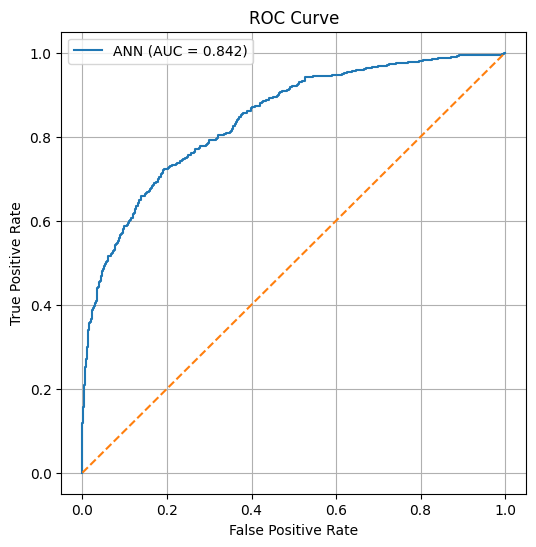

In [184]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## Results Analysis


#### In this experiment, class imbalance was handled using SMOTE with a controlled sampling strategy (sampling_strategy = 0.6). Instead of using the default threshold (0.5), an optimized threshold (≈ 0.32) was selected based on validation performance to balance recall and Macro F1-score.

#### On the test set, the model achieved a Macro F1-score of about 0.75 and a ROC-AUC of around 0.84. Recall for the churn class improved to approximately 0.61 while maintaining reasonable precision (~0.59), resulting in a more balanced trade-off between false positives and false negatives.

#### In previous experiments with Focal Loss, recall increased significantly but precision dropped sharply, leading to many false positives. Compared to that setup, SMOTE combined with threshold tuning provides a more stable and practically balanced performance.